#Lab Activity 08

The lab brief for this assignment is a single problem statement with no solved
activities, so this notebook builds the groundwork the graded task needs: what a
**Hopfield network** is, how to store patterns in one, and — most importantly —
the two conditions under which it stops working.

A Hopfield network is an **associative memory**, not a classifier. Every neuron
is connected to every other, there are no layers and no forward direction, and
the network has no output to train. Patterns are written into the weights in one
shot, and afterwards the network *recalls* the stored pattern that best matches
whatever it is shown.

**The three rules.**

1. **State.** Each of the `N` neurons holds `+1` or `-1`. The state of the whole
   network is a vector of those values — for a 28x28 image, 784 of them.
2. **Storage (the Hebbian rule).** To store patterns
   $\xi^1 \ldots \xi^p$, set

   $$W_{ij} = \frac{1}{N}\sum_{\mu} \xi^{\mu}_i \xi^{\mu}_j, \qquad W_{ii} = 0$$

   Two neurons that agree across the stored patterns get a positive weight; two
   that disagree get a negative one. The diagonal is zeroed so no neuron feeds
   back into itself.
3. **Recall.** Repeatedly set $s_i \leftarrow \mathrm{sign}(\sum_j W_{ij} s_j)$
   until nothing changes. The state that results is a **fixed point** — an
   attractor of the network.

**Why it converges.** The network has an energy

$$E = -\tfrac{1}{2}\sum_{i \neq j} W_{ij} s_i s_j$$

and the stored patterns are designed to sit at the bottoms of its valleys.

The guarantee comes with a condition that is easy to gloss over: energy is
non-increasing when neurons are updated **asynchronously** — one at a time, in
some order. Flipping neuron `i` only changes `E` by an amount that cannot be
positive, and since `E` is bounded below the network must settle.

Updating **synchronously** — recomputing every neuron at once from the same
previous state — has no such guarantee. It is faster and usually converges
anyway, but it can fall into a two-state cycle that flips back and forth
forever. Both modes are implemented below, and the energy is measured under
each.

##Activity 1: Storing and recalling patterns

Three 8x8 patterns — a cross, a hollow square and a diagonal X — written into a
64-neuron network.

###The patterns

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

ON_COLOR = "#2a78d6"
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e6e5e0"

SIZE = 8
N = SIZE * SIZE

PATTERN_ART = {
    "cross": ["...##...",
              "...##...",
              "...##...",
              "########",
              "########",
              "...##...",
              "...##...",
              "...##..."],
    "square": ["########",
               "#......#",
               "#......#",
               "#......#",
               "#......#",
               "#......#",
               "#......#",
               "########"],
    "diagonal": ["##....##",
                 "##....##",
                 "..####..",
                 "..####..",
                 "..####..",
                 "..####..",
                 "##....##",
                 "##....##"],
}


def art_to_pattern(rows):
    """'#' becomes +1, '.' becomes -1."""
    return np.array([[1 if ch == "#" else -1 for ch in row] for row in rows]).flatten()


names = list(PATTERN_ART)
patterns = np.array([art_to_pattern(PATTERN_ART[n]) for n in names])

print("Stored patterns:", patterns.shape, "->", len(patterns), "patterns of", N, "neurons")

# How similar are they? Hopfield assumes near-orthogonal patterns.
overlap = patterns @ patterns.T / N
print("\nOverlap between patterns (1 = identical, 0 = orthogonal):")
print(np.round(overlap, 3))

Stored patterns: (3, 64) -> 3 patterns of 64 neurons

Overlap between patterns (1 = identical, 0 = orthogonal):
[[ 1.    -0.25  -0.125]
 [-0.25   1.    -0.125]
 [-0.125 -0.125  1.   ]]


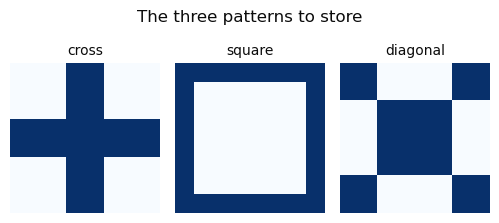

In [2]:
def show_patterns(images, titles, suptitle=None, size=SIZE):
    """Draw a row of bipolar patterns as black-and-white squares."""
    count = len(images)
    figure, axes_row = plt.subplots(1, count, figsize=(1.7 * count, 2.1))
    if count == 1:
        axes_row = [axes_row]
    for image, title, axes in zip(images, titles, axes_row):
        axes.imshow(image.reshape(size, size), cmap="Blues", vmin=-1, vmax=1)
        axes.set_title(title, fontsize=10, color=INK)
        axes.set_xticks([])
        axes.set_yticks([])
        for spine in axes.spines.values():
            spine.set_visible(False)
    if suptitle:
        figure.suptitle(suptitle, fontsize=12, color=INK, y=1.04)
    plt.tight_layout()
    plt.show()


show_patterns(patterns, names, "The three patterns to store")

###The network

In [3]:
def hebbian_weights(patterns):
    """W = (1/N) * sum of outer products, with a zero diagonal."""
    P = np.asarray(patterns, dtype=float)
    W = P.T @ P / P.shape[1]
    np.fill_diagonal(W, 0.0)
    return W


def energy(state, W):
    """E = -0.5 * s W s. Every update either lowers this or leaves it alone."""
    s = np.asarray(state, dtype=float)
    return -0.5 * s @ W @ s


def recall(state, W, max_iter=30, record=False):
    """Synchronous recall: every neuron is recomputed at once, from the same
    previous state. Fast, but with no guarantee that energy decreases."""
    s = np.asarray(state, dtype=float).copy()
    history = [s.copy()]
    for step in range(max_iter):
        new = np.sign(W @ s)
        new[new == 0] = 1          # break ties towards +1
        if np.array_equal(new, s):
            break
        s = new
        if record:
            history.append(s.copy())
    return (s, history) if record else s


def recall_async(state, W, sweeps=8, rng=None, record=False):
    """Asynchronous recall: one neuron at a time, in random order. This is the
    version the energy guarantee applies to."""
    rng = rng or np.random.default_rng(0)
    s = np.asarray(state, dtype=float).copy()
    trace = [energy(s, W)]
    for _ in range(sweeps):
        changed = False
        for i in rng.permutation(len(s)):
            value = np.sign(W[i] @ s)
            if value == 0:
                value = 1
            if value != s[i]:
                s[i] = value
                changed = True
            if record:
                trace.append(energy(s, W))
        if not changed:
            break
    return (s, trace) if record else s


W = hebbian_weights(patterns)
print("Weight matrix:", W.shape)
print("Diagonal is zero:", np.allclose(np.diag(W), 0))
print("Symmetric:", np.allclose(W, W.T))

print("\nAre the stored patterns fixed points?")
for name, pattern in zip(names, patterns):
    settled = recall(pattern, W)
    print("  %-9s stable: %-5s | energy %.2f" % (
        name, bool(np.array_equal(settled, pattern)), energy(pattern, W)))

Weight matrix: (64, 64)
Diagonal is zero: True
Symmetric: True

Are the stored patterns fixed points?
  cross     stable: True  | energy -33.00
  square    stable: True  | energy -33.00
  diagonal  stable: True  | energy -31.50


###Recall from a corrupted pattern

This is what a Hopfield network is *for*. A pattern is damaged — a percentage of
its pixels flipped at random — and the network is left to settle. If the damaged
version is still inside the right energy valley, the network rolls back down to
the original.

10% of pixels flipped -> recovered exactly: True (64 of 64 pixels correct)
25% of pixels flipped -> recovered exactly: True (64 of 64 pixels correct)
40% of pixels flipped -> recovered exactly: True (64 of 64 pixels correct)


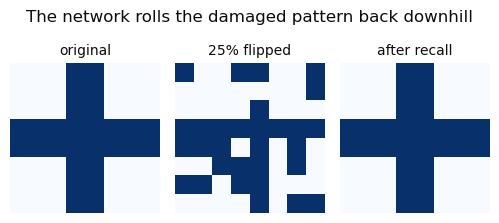

In [4]:
rng = np.random.default_rng(42)


def corrupt(pattern, fraction, rng):
    """Flip a random fraction of the pixels."""
    noisy = pattern.copy()
    n_flip = int(fraction * len(pattern))
    flip_at = rng.choice(len(pattern), size=n_flip, replace=False)
    noisy[flip_at] *= -1
    return noisy


target = patterns[0]                     # the cross
for fraction in (0.1, 0.25, 0.4):
    damaged = corrupt(target, fraction, rng)
    restored = recall(damaged, W)
    recovered = np.array_equal(restored, target)
    print("%.0f%% of pixels flipped -> recovered exactly: %s (%d of %d pixels correct)" % (
        fraction * 100, recovered, int((restored == target).sum()), N))

damaged = corrupt(target, 0.25, rng)
restored = recall(damaged, W)
show_patterns([target, damaged, restored],
              ["original", "25% flipped", "after recall"],
              "The network rolls the damaged pattern back downhill")

###Energy only goes down - under asynchronous updates

Here is the energy measured after **every individual neuron update**, during an
asynchronous recall from a badly damaged pattern. Each step either lowers the
energy or leaves it alone, and the network comes to rest at the bottom.

The synchronous version is run on the same input for comparison. It reaches the
same place in far fewer steps, which is why it is used everywhere else in these
notebooks - but it is the asynchronous version that carries the guarantee.

Asynchronous recall: 128 single-neuron updates
  energy -1.88 -> -33.00
  every step non-increasing: True
  recovered the stored pattern: True

Synchronous recall: 1 full sweeps, energy [ -1.88 -33.  ]
  recovered the stored pattern: True


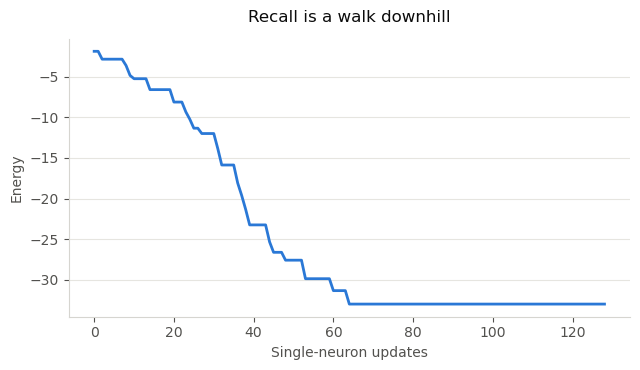

In [5]:
damaged = corrupt(patterns[1], 0.35, rng)      # the square

settled_async, energies = recall_async(damaged, W, rng=np.random.default_rng(0), record=True)
print("Asynchronous recall: %d single-neuron updates" % (len(energies) - 1))
print("  energy %.2f -> %.2f" % (energies[0], energies[-1]))
print("  every step non-increasing:",
      all(b <= a + 1e-9 for a, b in zip(energies, energies[1:])))
print("  recovered the stored pattern:", np.array_equal(settled_async, patterns[1]))

settled_sync, history = recall(damaged, W, record=True)
sync_energies = [energy(state, W) for state in history]
print()
print("Synchronous recall: %d full sweeps, energy %s" % (
    len(sync_energies) - 1, np.round(sync_energies, 2)))
print("  recovered the stored pattern:", np.array_equal(settled_sync, patterns[1]))

figure, axes = plt.subplots(figsize=(6.5, 3.8))
axes.plot(range(len(energies)), energies, color=ON_COLOR, linewidth=2)
axes.set_xlabel("Single-neuron updates", color=INK_SOFT)
axes.set_ylabel("Energy", color=INK_SOFT)
axes.set_title("Recall is a walk downhill", color=INK, fontsize=12, pad=12)
axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.yaxis.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)
plt.tight_layout()
plt.show()

##Activity 2: The two things that break a Hopfield network

The graded task stores ten digit prototypes in a 784-neuron network. Whether
that can work at all depends on two limits, and both are worth establishing
before relying on them.

###Limit 1: capacity

A Hopfield network can only hold so many patterns. The standard result is that
**about 0.138N** random patterns can be stored before recall collapses — for
`N = 64` that is roughly 9.

Below, `p` random patterns are stored and then immediately recalled. Perfect
recall of a pattern the network was *just given* is the easiest possible test,
so anything below 100% means the memory is already failing.

In [6]:
def capacity_check(n_neurons, n_patterns, trials=20, seed=0):
    """Fraction of stored patterns that are still stable fixed points."""
    rng = np.random.default_rng(seed)
    stable = 0
    total = 0
    for _ in range(trials):
        stored = rng.choice([-1, 1], size=(n_patterns, n_neurons))
        weights = hebbian_weights(stored)
        for pattern in stored:
            settled = recall(pattern, weights, max_iter=1)
            stable += int(np.array_equal(settled, pattern))
            total += 1
    return stable / total


theoretical = 0.138 * N
print("For N = %d neurons the classic capacity limit is about %.1f patterns\n" % (N, theoretical))

pattern_counts = [2, 4, 6, 8, 10, 12, 16, 20]
stability = [capacity_check(N, p) for p in pattern_counts]
for p, frac in zip(pattern_counts, stability):
    print("  %2d patterns stored -> %.1f%% of them are stable" % (p, 100 * frac))

For N = 64 neurons the classic capacity limit is about 8.8 patterns



   2 patterns stored -> 100.0% of them are stable
   4 patterns stored -> 100.0% of them are stable
   6 patterns stored -> 100.0% of them are stable
   8 patterns stored -> 89.4% of them are stable
  10 patterns stored -> 85.0% of them are stable
  12 patterns stored -> 63.3% of them are stable
  16 patterns stored -> 29.7% of them are stable
  20 patterns stored -> 9.8% of them are stable


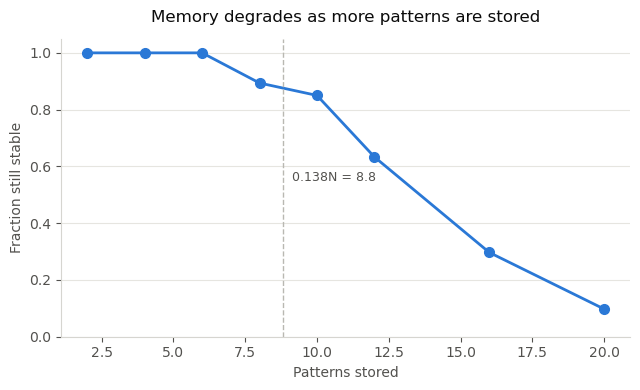

In [7]:
figure, axes = plt.subplots(figsize=(6.5, 4))

axes.plot(pattern_counts, stability, color=ON_COLOR, linewidth=2,
          marker="o", markersize=7)
axes.axvline(theoretical, color="#b9b8b2", linewidth=1, linestyle="--")
axes.text(theoretical + 0.3, 0.55, "0.138N = %.1f" % theoretical,
          color=INK_SOFT, fontsize=9)

axes.set_xlabel("Patterns stored", color=INK_SOFT)
axes.set_ylabel("Fraction still stable", color=INK_SOFT)
axes.set_title("Memory degrades as more patterns are stored",
               color=INK, fontsize=12, pad=12)
axes.set_ylim(0, 1.05)
axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.yaxis.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)
plt.tight_layout()
plt.show()

###Limit 2: correlation — the one that matters for digits

Capacity is the limit that gets quoted, but it assumes the stored patterns are
**random and roughly orthogonal**. Handwritten digits are nothing of the sort:
every digit is a blob of ink in the middle of a 28x28 frame, so any two digit
prototypes overlap heavily.

The experiment below stores the same small number of patterns twice — once
random, once deliberately correlated (each built from a shared base with only a
fraction of pixels changed) — and checks whether they are still recallable.

In [8]:
def correlated_patterns(n_patterns, n_neurons, difference, rng):
    """Patterns that share a common base, differing in `difference` of pixels."""
    base = rng.choice([-1, 1], size=n_neurons)
    out = []
    for _ in range(n_patterns):
        pattern = base.copy()
        flip_at = rng.choice(n_neurons, size=int(difference * n_neurons), replace=False)
        pattern[flip_at] *= -1
        out.append(pattern)
    return np.array(out)


rng = np.random.default_rng(1)
n_store = 4

print("Storing %d patterns in %d neurons - well inside the capacity limit.\n" % (n_store, N))

for label, stored in (
        ("random (near-orthogonal)", rng.choice([-1, 1], size=(n_store, N))),
        ("correlated (30% different)", correlated_patterns(n_store, N, 0.30, rng)),
        ("correlated (15% different)", correlated_patterns(n_store, N, 0.15, rng))):
    weights = hebbian_weights(stored)
    stable = sum(int(np.array_equal(recall(p, weights), p)) for p in stored)
    off_diagonal = (stored @ stored.T / N)[~np.eye(n_store, dtype=bool)]
    print("%-28s mean overlap %.2f -> %d of %d patterns stable" % (
        label, np.abs(off_diagonal).mean(), stable, n_store))

Storing 4 patterns in 64 neurons - well inside the capacity limit.

random (near-orthogonal)     mean overlap 0.09 -> 4 of 4 patterns stable
correlated (30% different)   mean overlap 0.23 -> 4 of 4 patterns stable
correlated (15% different)   mean overlap 0.53 -> 0 of 4 patterns stable


**This is the result the graded task turns on.** Four patterns is far inside the
capacity limit, and when they are random the network stores them without
trouble. Make them correlated and the same network — same size, same number of
patterns — loses them.

The reason is that the Hebbian rule simply adds the patterns together. When they
share structure, those shared parts reinforce each other and swamp the
differences, so the energy landscape ends up with one broad valley where there
should have been several separate ones. Everything rolls into the same place.

Ten MNIST digit prototypes are **more** correlated than the worst case above.
The graded task measures exactly how correlated, and what it does to recall.

#End!